# Identifying Problem Stocks
In this notebook I will identify potential outlier stocks that show abnormal return 
trends with disproportional risk.

Black swan events such as the 2008 financial crisis, COVID-19, the dotcom bubble burst,
GameStop bull run may be legitimate reasons for outlier returns.

However, sometimes financial data may be corrupted for illegitimate reasons including,
double counting, acquisitions & mergers, bankruptcies etc.

It is important to identify potentially corrupted data so that it does not intefere with
algorithm testing and signal generation.

## Imports

In [3]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-06-08 11:34:31.707 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [4]:
# Load a complete collection of S&P500 stocks from repository
# Not interested in survivors here
df_stocks = tad.get_sp500(survivors=False).Close

In [5]:
ht(df_stocks)

Ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,1.473408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.088754,NaN,0.635471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090072,NaN,0.647386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090292,NaN,0.643414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-12,111.629997,65.930000,10.55,52.660000,255.759995,225.369995,127.699997,NaN,108.139999,94.220001,...,153.529999,11.80,1.710000,120.019997,59.900002,158.460007,92.589996,204.050003,54.240002,115.459999
2026-03-13,111.510002,63.590000,10.30,51.730000,250.119995,219.679993,126.300003,NaN,108.029999,93.470001,...,156.119995,11.54,1.660000,119.879997,59.790001,160.399994,93.199997,202.720001,53.099998,115.620003
2026-03-16,111.830002,66.599998,10.49,53.189999,252.820007,221.449997,128.320007,NaN,109.949997,93.699997,...,157.229996,11.73,1.540000,121.070000,59.849998,161.779999,93.300003,203.970001,53.540001,118.150002


## Identifying Outliers

In [6]:
def boxplot(title=''):

    fig, ax = plt.subplots(2,1, figsize=(12,6), tight_layout=True)
    plt.suptitle(title)

    ax[0].spines[['left','right']].set_visible(False)
    ax[0].tick_params(top=False,
                    bottom=False,
                    left=False,
                    right=False,
                    labelleft=False,
                    labelbottom=False)
    ax[0].set_ylabel('Risk', rotation=45, fontsize=12)
    sns.boxplot(df_agg[['Risk']], ax=ax[0], orient='h')

    ax[1].spines[['left','top','right']].set_visible(False)
    ax[1].tick_params(top=False,
                    bottom=False,
                    left=False,
                    right=False,
                    labelleft=False,
                    labelbottom=False)
    ax[1].set_ylabel('Return', rotation=45, fontsize=12)
    sns.boxplot(df_agg[['Return']], ax=ax[1], orient='h')

    plt.show();

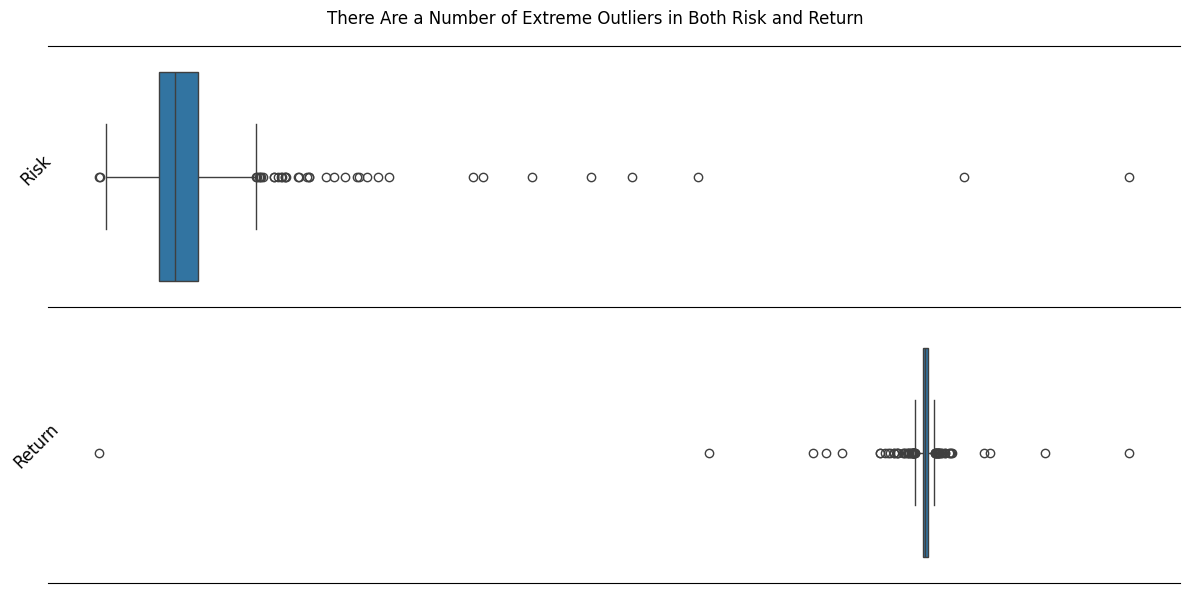

In [7]:
# Convert to log prices
log_prices = np.log(df_stocks)

# 3 Month Rolling Returns
log_returns = log_prices - log_prices.shift(63)

# Calculate Log Risk / Return
df_agg = log_returns.agg({'mean', 'std'}).rename({'mean': 'Return', 'std': 'Risk'}).T

# Annualize Log Risk / Return
df_agg = df_agg * (np.sqrt(4), 4)

# Get the upper and lower IQR bounds for outliers
outlier_bounds = df_agg.apply(tau.outlier_bounds, method='IQR')

# Identify stocks that sit beyond outlier thresholds for risk or return
df_outliers = df_agg[((df_agg > outlier_bounds.iloc[1]) | (df_agg < outlier_bounds.iloc[0]))\
                     .any(axis=1)]\
                        .sort_values(['Risk', 'Return'], ascending=False)

# Save list of tickers of potential outliers
outliers = df_outliers.index.to_list()

boxplot('There Are a Number of Extreme Outliers in Both Risk and Return')

In [8]:
def trends(tickers,
           title='Log Price Trend of Outlier Stocks',
           txt='',
           ncols=5):
    
    ncols = min(ncols, len(tickers))
    nrows = int(np.ceil(len(tickers)/ncols))
    figlength = 1.5*nrows
    titlepad = 1 if txt != '' else 1
    padtop = figlength / (figlength + titlepad)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, figlength + titlepad), tight_layout=True)
    fig.tight_layout(pad=2, rect=[0, 0, 1, padtop])
    fig.suptitle(title, fontsize=16, y=1)
    fig.text(y=(1-(1-padtop)/2),
             x=0.5,
             s=txt,
             horizontalalignment='center',
             verticalalignment='center')
    
    for i, ticker in enumerate(tickers):

        if nrows > 1:
            ax_p = axes[int(i/ncols), i%ncols]
        else:
            ax_p = axes[i%ncols]

        ax_p.set_title(f"{ticker}")
        ax_p.set_yticklabels([])
        ax_p.set_yticks([])
        ax_p.set_ylabel(' ')
        ax_p.set_xticklabels([])
        ax_p.set_xticks([])
        ax_p.set_xlabel(' ')
        ax_p.spines[['top','bottom','left','right']].set_visible(False)

        ax_p.plot((log_prices[ticker]), linewidth=0.5)

    # Determine how many empty plots there are on the last row of the figure
    num_empty_plots = nrows * ncols - len(tickers)
    if num_empty_plots > 0:
        for i in range(1, num_empty_plots + 1):
            # Hide empty plots
            if nrows > 1:
                axes[nrows - 1, ncols - i].set_axis_off()
            else:
                axes[ncols-i].set_axis_off()

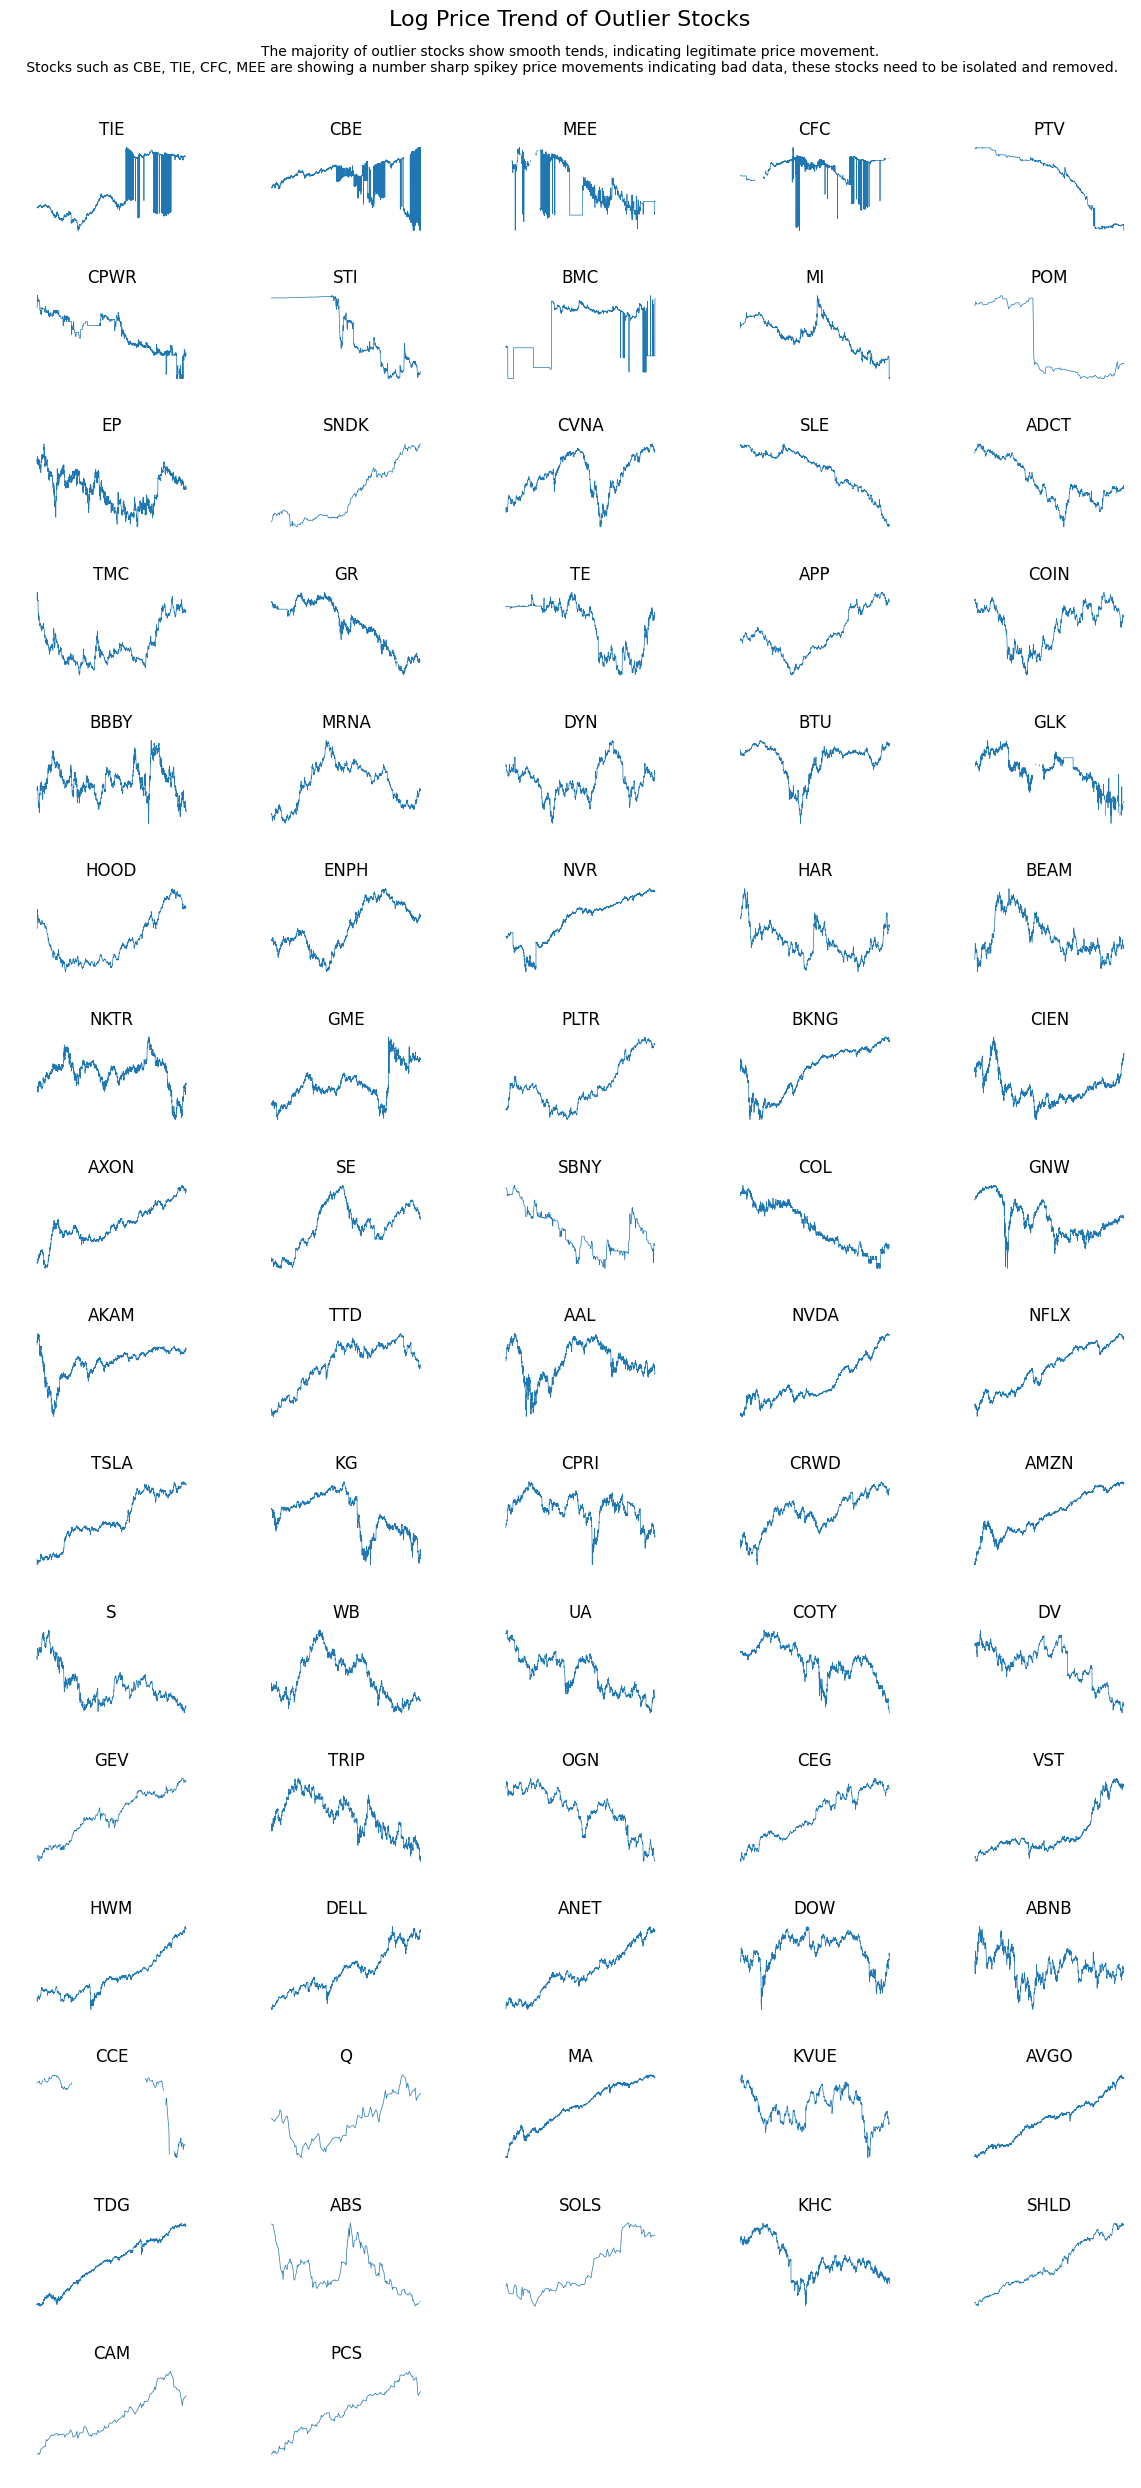

In [9]:
txt = 'The majority of outlier stocks show smooth tends, indicating legitimate price '\
      'movement.\n Stocks such as CBE, TIE, CFC, MEE are showing a number sharp spikey '\
      'price movements indicating bad data, these stocks need to be isolated and removed.'

trends(tickers=outliers,
       txt=txt)

## Isolating The Bad Data

In [10]:
# Daily Log Returns
log_returns = (log_prices - log_prices.shift(1))

#### Identifying Isolated Spikes

In [11]:
# Abnormaly large price changes directly both preceded and followed by
# comparatively small price movements.
isolated_spikes = (
    # Abnormaly large daily change (> 170%)
    abs(log_returns > 1).mask(log_returns.isna(), np.nan) &
    # Followed by a comparatively smally daily change (< 10.5%)
    (abs(log_returns.shift(1) < 0.1).mask(log_returns.isna(), np.nan) &
    # Preceded by a comparitively small daily change (< 10.5%)
     abs(log_returns.shift(-1) < 0.1).mask(log_returns.isna(), np.nan))
    ).sum()

#### Identifying Spikes with Immediate Reversal

In [12]:
# Abnormaly large price changes followed directly by an abnormaly large
# reversal.
reversal_spikes = (
    (((log_returns > 1) & (log_returns.shift(1) < -1)) | 
     ((log_returns < 1) & (log_returns.shift(1) > 1)))
).sum()

#### Identifying Large Residuals

In [13]:
# Identifying all abnormal price movements that deviate enourmously
# from the monthly median price
rolling_med = log_returns.rolling(21).median()
residual_spikes = (abs(log_returns - rolling_med) > 2).sum()

#### Combining

In [14]:
problem_counts = pd.concat(
    [isolated_spikes[isolated_spikes!=0],
     reversal_spikes[reversal_spikes!=0],
     residual_spikes[residual_spikes!=0]], 
    axis=1)\
        .fillna(0)\
            .astype(int)
problem_counts.columns = ['Isolated Spikes', 'Spike Reversals', 'Extreme Price Movements']
problem_tickers = problem_counts.index.tolist()
problem_counts

,Isolated Spikes,Spike Reversals,Extreme Price Movements
Ticker,,,
BMC,16,19,28
CBE,413,617,698
CFC,69,120,108
CPWR,16,21,7
EP,3,3,0
GLK,4,6,0
HUBB,1,1,1
MEE,44,72,62
NVR,1,1,1


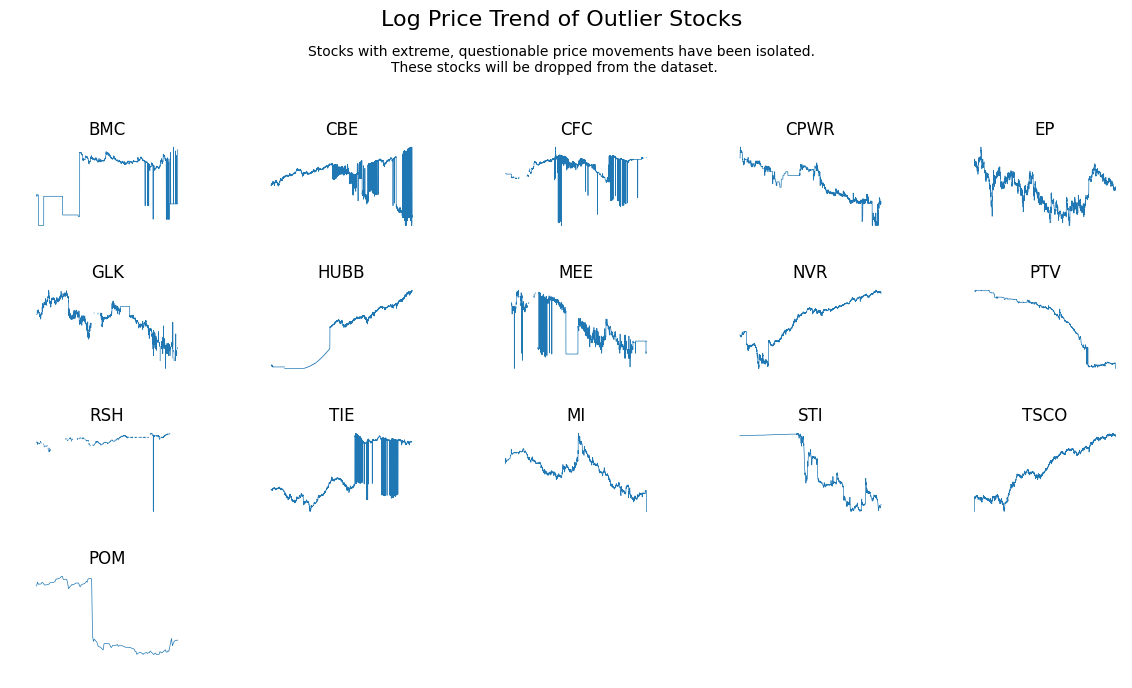

In [16]:
txt = 'Stocks with extreme, questionable price movements have been isolated.\n' \
      'These stocks will be dropped from the dataset.   '

trends(tickers=problem_tickers,
       txt=txt)

## Removing Problem Stocks

In [17]:
df_stocks = df_stocks.drop(problem_tickers, axis=1)

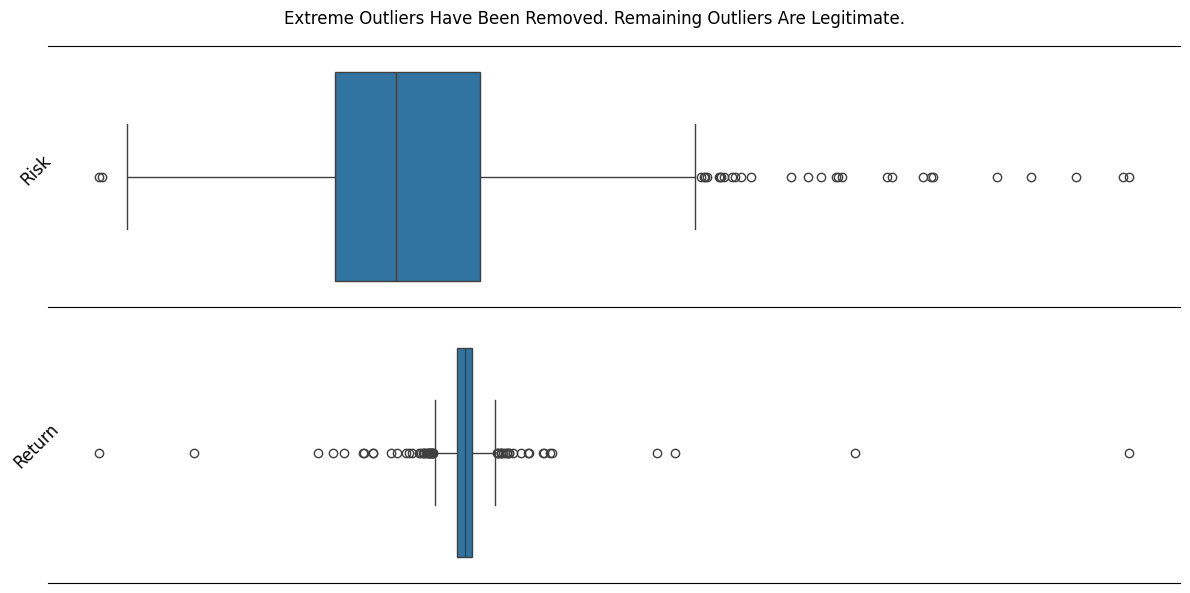

In [18]:
# Convert to log prices
log_prices = np.log(df_stocks)

# 3 Month Rolling Returns
log_returns = log_prices - log_prices.shift(63)

# Calculate Log Risk / Return
df_agg = log_returns.agg({'mean', 'std'}).rename({'mean': 'Return', 'std': 'Risk'}).T

# Annualize Log Risk / Return
df_agg = df_agg * (np.sqrt(4), 4)

# Get the upper and lower IQR bounds for outliers
outlier_bounds = df_agg.apply(tau.outlier_bounds, method='IQR')

# Identify stocks that sit beyond outlier thresholds for risk or return
df_outliers = df_agg[((df_agg > outlier_bounds.iloc[1]) | (df_agg < outlier_bounds.iloc[0]))\
                     .any(axis=1)]\
                        .sort_values(['Risk', 'Return'], ascending=False)

# Save list of tickers of potential outliers
outliers = df_outliers.index.to_list()

boxplot('Extreme Outliers Have Been Removed. Remaining Outliers Are Legitimate.')

## Identifying Tickers with Intermittent Data

In [19]:
def get_nulls(s = pd.Series):
    
    start = s.first_valid_index()
    end = s.last_valid_index()
    
    if (start == None) | (end == None):
        return np.nan

    s_valid = s.loc[start: end].copy()
    
    nulls = s_valid.isna() * 1

    if nulls.sum() == 0:
        return np.nan
    
    nulls_periods =(
        ((nulls.diff().fillna(nulls.iloc[0]) == 1) * 1)\
            .mask(nulls==False,np.nan)\
                .cumsum())
    
    stats = nulls_periods.value_counts()\
                .agg(['count', 'mean', 'max', 'sum']).astype(int)
    
    stats['pct'] = nulls.mean() * 100

    stats.index=['Null Events', 'Avg Duration', 'Max Duration', 'Tot Missing', 'Pct Null']

    return stats.round(2)

In [ ]:
def nulls_summary(stats = pd.Series):

    stats = log_prices.apply(get_nulls)

    stats = stats[stats.notna()]

    df_null = pd.DataFrame(stats.tolist(), index=stats.index)

    df_null[df_null.columns[:4]] = df_null[df_null.columns[:4]].astype(int)

    return df_null

In [28]:
df_nulls = nulls_summary(df_stocks.apply(get_nulls))
df_nulls

,Null Events,Avg Duration,Max Duration,Tot Missing,Pct Null
Ticker,,,,,
ABS,1,1,1,1,0.51
CCE,6,26,121,158,53.38
COL,41,1,1,41,1.96
EVHC,1,1,1,1,0.08
FISV,1,1,1,1,0.01
GR,52,2,15,114,2.64
HAR,4,3,4,12,0.52
LMT,1,1,1,1,0.01
MHS,72,1,2,74,4.84


In [29]:
# Dropping any tickers that have more than 5% of data missing
# or have atleast one period of 5 or more consecutive missing data points
problem_tickers = df_nulls[(df_nulls['Max Duration'] > 4) | (df_nulls['Pct Null'] >= 5)].index.tolist()

# Remaining tickers with missing data points will be smoothed out with
# the rolling weekly median
smooth_tickers = df_nulls.drop(problem_tickers).index.tolist()

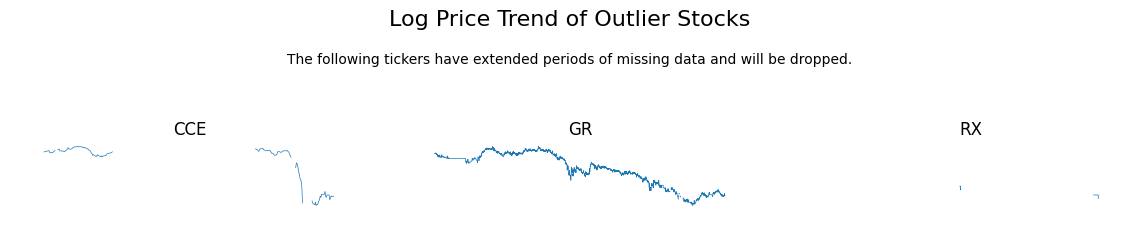

In [30]:
title = f'Log Price Trend of Outlier Stocks'
txt = 'The following tickers have extended periods of missing data and will be dropped.'

trends(tickers=problem_tickers,
        title=title,
        txt=txt,
        ncols=3)

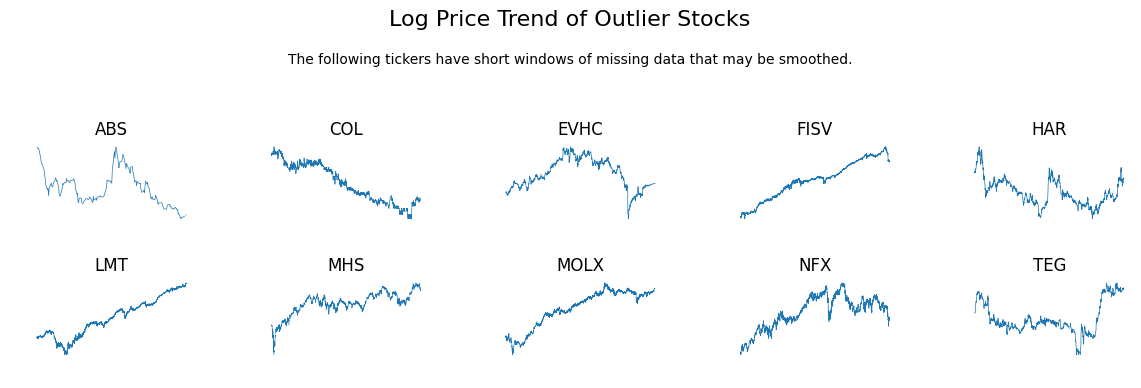

In [32]:
title = f'Log Price Trend of Outlier Stocks'
txt = 'The following tickers have short windows of missing data that may be smoothed.'

trends(tickers=smooth_tickers,
        title=title,
        txt=txt,
        ncols=5)

<Axes: xlabel='Date'>

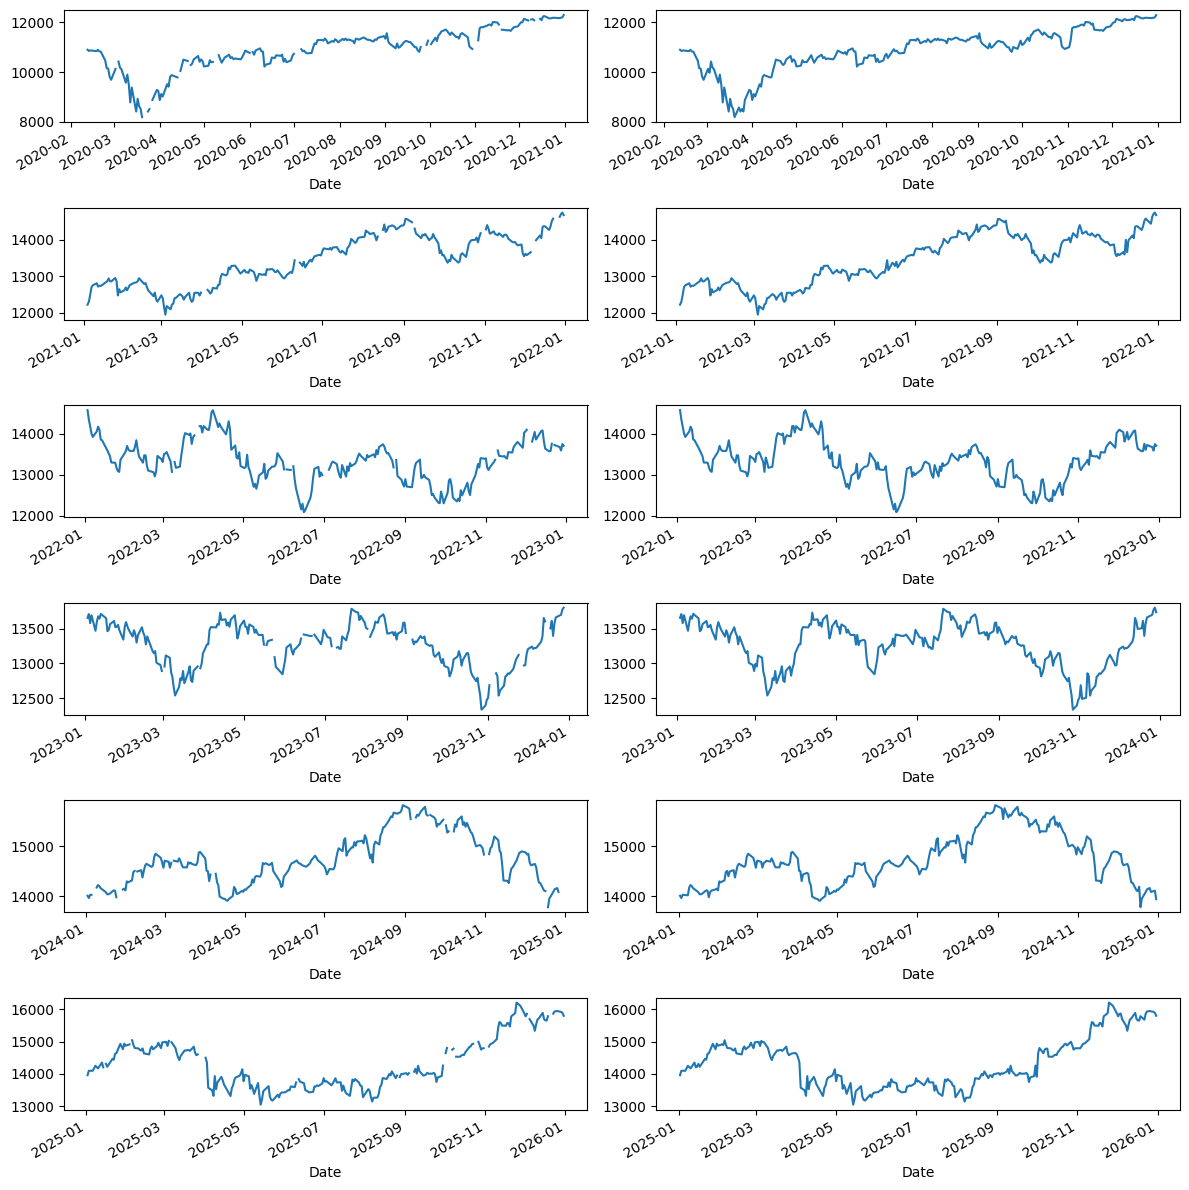

In [62]:
fig, axes = plt.subplots(6, 2, figsize=(12, 12), tight_layout=True)

df_stocks.loc['2020','MHS'].plot(ax=axes[0,0])
df_stocks.loc['2020','MHS'].fillna(df_stocks.loc['2020','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[0,1])

df_stocks.loc['2021','MHS'].plot(ax=axes[1,0])
df_stocks.loc['2021','MHS'].fillna(df_stocks.loc['2021','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[1,1])

df_stocks.loc['2022','MHS'].plot(ax=axes[2,0])
df_stocks.loc['2022','MHS'].fillna(df_stocks.loc['2022','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[2,1])

df_stocks.loc['2023','MHS'].plot(ax=axes[3,0])
df_stocks.loc['2023','MHS'].fillna(df_stocks.loc['2023','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[3,1])

df_stocks.loc['2024','MHS'].plot(ax=axes[4,0])
df_stocks.loc['2024','MHS'].fillna(df_stocks.loc['2024','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[4,1])

df_stocks.loc['2025','MHS'].plot(ax=axes[5,0])
df_stocks.loc['2025','MHS'].fillna(df_stocks.loc['2025','MHS'].rolling(5, min_periods=1).median()).plot(ax=axes[5,1])

<Axes: xlabel='Date'>

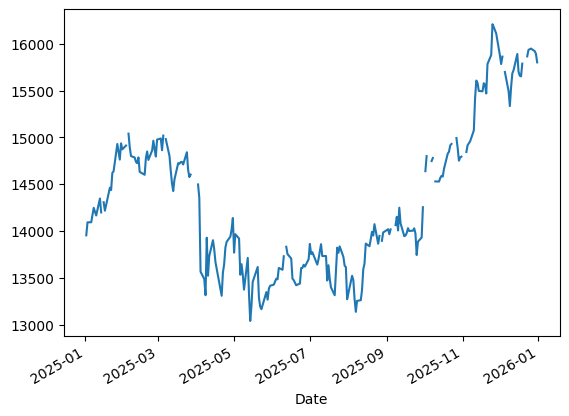

In [61]:
s = df_stocks['MHS'].loc[df_stocks['MHS'].first_valid_index(): df_stocks['MHS'].last_valid_index()]
s.loc['2025'].plot()

In [ ]:
s.fillna(s.rolling(4, min_periods=1).median()).loc['2025'].plot()

In [ ]:
problem_tickers = df_null.index.tolist()

In [ ]:
title = f'Log Price Trend of Outlier Stocks'
txt = 'The following tickers have extended periods of missing data and will be dropped.'

trends(tickers=problem_tickers,
        title=title,
        txt=txt,
        ncols=3)

In [ ]:
s = log_prices['GR'].loc[log_prices['GR'].first_valid_index(): log_prices['GR'].last_valid_index()]
s.plot()

In [ ]:
s.fillna(s.rolling(5, min_periods=1).median()).plot()

In [ ]:
s.fillna(s.rolling(7, min_periods=1).median()).isna().any()

In [ ]:
log_prices['COL'].loc[log_prices['COL'].first_valid_index(): log_prices['COL'].last_valid_index()].plot()